In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict

In [2]:
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import lev_win_multi, lev_win_distance, lev_win_multi_weighted, jaro_win
from modules.group_dr import add_multi_chart

In [3]:
df = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/Data/surveys (1).csv')
df['SURVEY_DATE'] = pd.to_datetime(df['SURVEY_DATE'])

In [4]:
sample = df.head(2000)

In [5]:
sample.head()

,HASH,CLIENT_ID,SURVEY_WEEK,SURVEY_DATE,ADDRESS,EMAIL,POSITION,DISB_DATE,INDUSTRY,DISBURSED,DR1,DEFAULTED,PTFRAUD
0,ecpb0,178484003,2024-02-05,2024-02-05 09:36:39,Peace church,acquahmary574@gmail.com,Packaging,2024-02-05 09:40:44.000,Food Industry,1,0,0,0
1,NaN,844806159,2024-01-29,2024-01-30 23:10:06,GBC bank,hensy.ai@gmail.com,Owner,2024-01-30 23:29:41.000,Transportation,1,0,0,0
2,ecpb1,832139937,2024-01-22,2024-01-27 17:15:06,ATTA MILLS,arhinm220@gmail.com,DRIVER,2025-02-06 11:16:37.000,Transportation,1,0,1,0
3,ecy1p,279135133,2024-03-04,2024-03-05 21:10:31,old karaga street,NaN,accountant,2024-03-05 21:21:50.000,Healthcare,1,0,0,0
4,ebzze,368413062,2024-03-04,2024-03-06 19:42:23,Abebrese Street,dadzitheodora77@gmail.com,nurse,2024-03-19 08:52:37.000,Healthcare,1,0,0,0


In [6]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   HASH         1720 non-null   object        
 1   CLIENT_ID    2000 non-null   int64         
 2   SURVEY_WEEK  2000 non-null   object        
 3   SURVEY_DATE  2000 non-null   datetime64[ns]
 4   ADDRESS      2000 non-null   object        
 5   EMAIL        1262 non-null   object        
 6   POSITION     1919 non-null   object        
 7   DISB_DATE    2000 non-null   object        
 8   INDUSTRY     1919 non-null   object        
 9   DISBURSED    2000 non-null   int64         
 10  DR1          2000 non-null   int64         
 11  DEFAULTED    2000 non-null   int64         
 12  PTFRAUD      2000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(7)
memory usage: 203.3+ KB


Iterating over multiple similarity threholds

In [12]:
records = []
for i in range(2, 7):
    output = defaultdict(list) 
    res = jaro_win(df, 15, i, 0.90)
    res['dup_limit'] = i    
    output['dup_limit'] = i
    output['sim_threshold'] = 0.90
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)
address_dup_fraud = res.copy()

output1 = pd.DataFrame(records)

In [13]:
address_dup_fraud.to_csv('address_dup_fraud_jaro_wrinkler.csv')

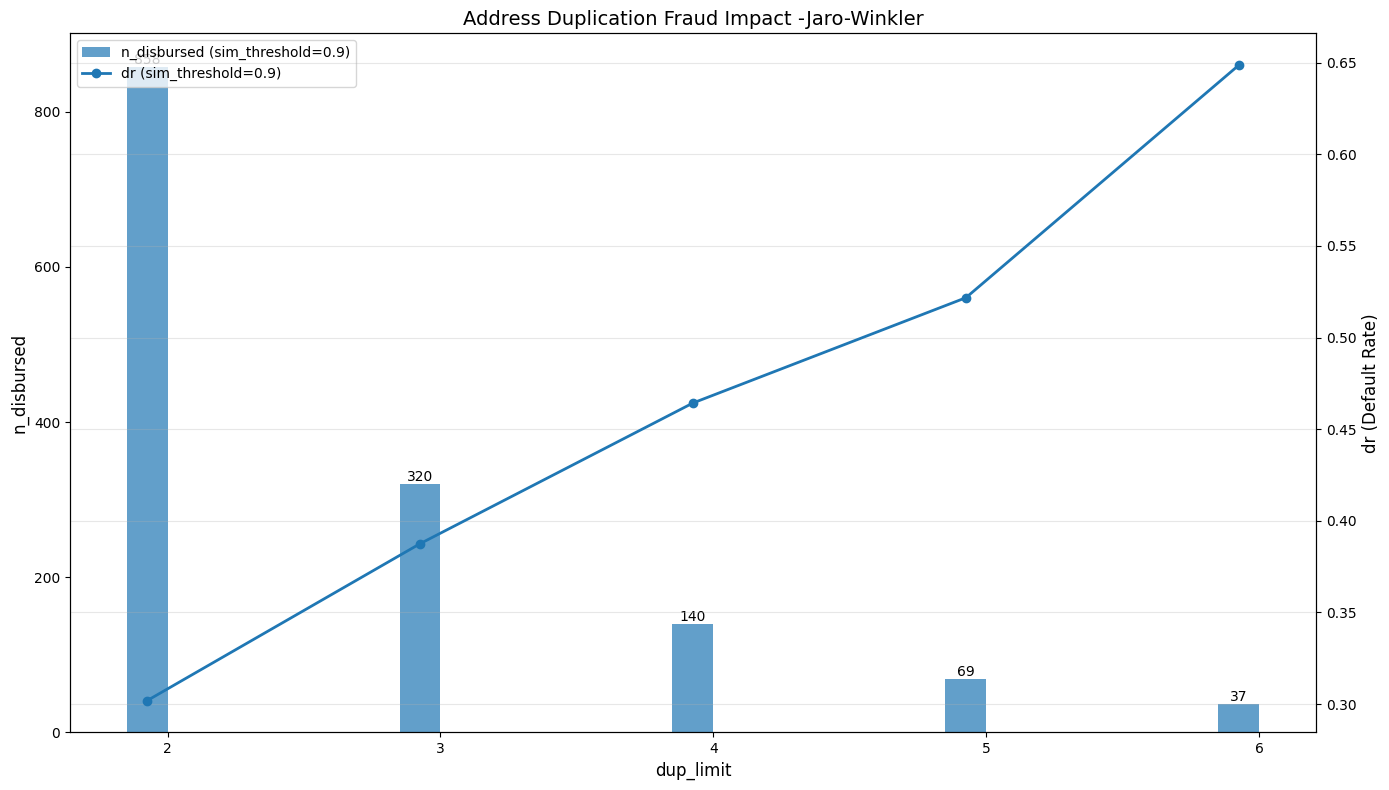

In [14]:
add_multi_chart(output1, 'Address Duplication Fraud Impact -Jaro-Winkler', 'dup_limit', 'sim_threshold')

In [15]:
# address_dup_fraud

In [17]:
output1

,dup_limit,sim_threshold,n_surveys,n_disbursed,dr
0,2,0.85,0,2546,0.240377
1,3,0.85,0,1369,0.257852
2,4,0.85,0,763,0.283093
3,5,0.85,0,462,0.287879
4,6,0.85,0,291,0.295533


In [16]:
records = []
for i in range(2, 7):
    for j in range(0, 4):
        output = defaultdict(list) 
        res = lev_win_distance(df, 15, i, j)
        res['dup_limit'] = i    
        output['dup_limit'] = i
        output['sim_threshold'] =j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
address_dup_fraud = res.copy()

output2 = pd.DataFrame(records)

KeyboardInterrupt: 

In [12]:
output2

,dup_limit,sim_threshold,n_surveys,n_disbursed,dr
0,2,3,0,859,0.307334
1,3,3,0,324,0.382716
2,4,3,0,145,0.441379
3,5,3,0,63,0.476190
4,6,3,0,30,0.600000


In [ ]:
address_dup_fraud.to_csv('address_dup_fraud_levenshtein.csv')

In [ ]:
add_multi_chart(output2, 'Address Duplication Fraud Impact-Levenshtein', 'dup_limit', 'sim_threshold')

In [20]:
records = []
for i in range(2, 7):
    output = defaultdict(list) 
    res = jaro_win(df, 15, i, 1)
    res['dup_limit'] = i    
    output['dup_limit'] = i
    output['sim_threshold'] =1
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)
address_dup_fraud = res.copy()

output3 = pd.DataFrame(records)

In [21]:
output3

,dup_limit,sim_threshold,n_surveys,n_disbursed,dr
0,2,1,284,137,0.510949
1,3,1,131,60,0.633333
2,4,1,72,30,0.733333
3,5,1,43,16,0.875000
4,6,1,26,10,0.900000


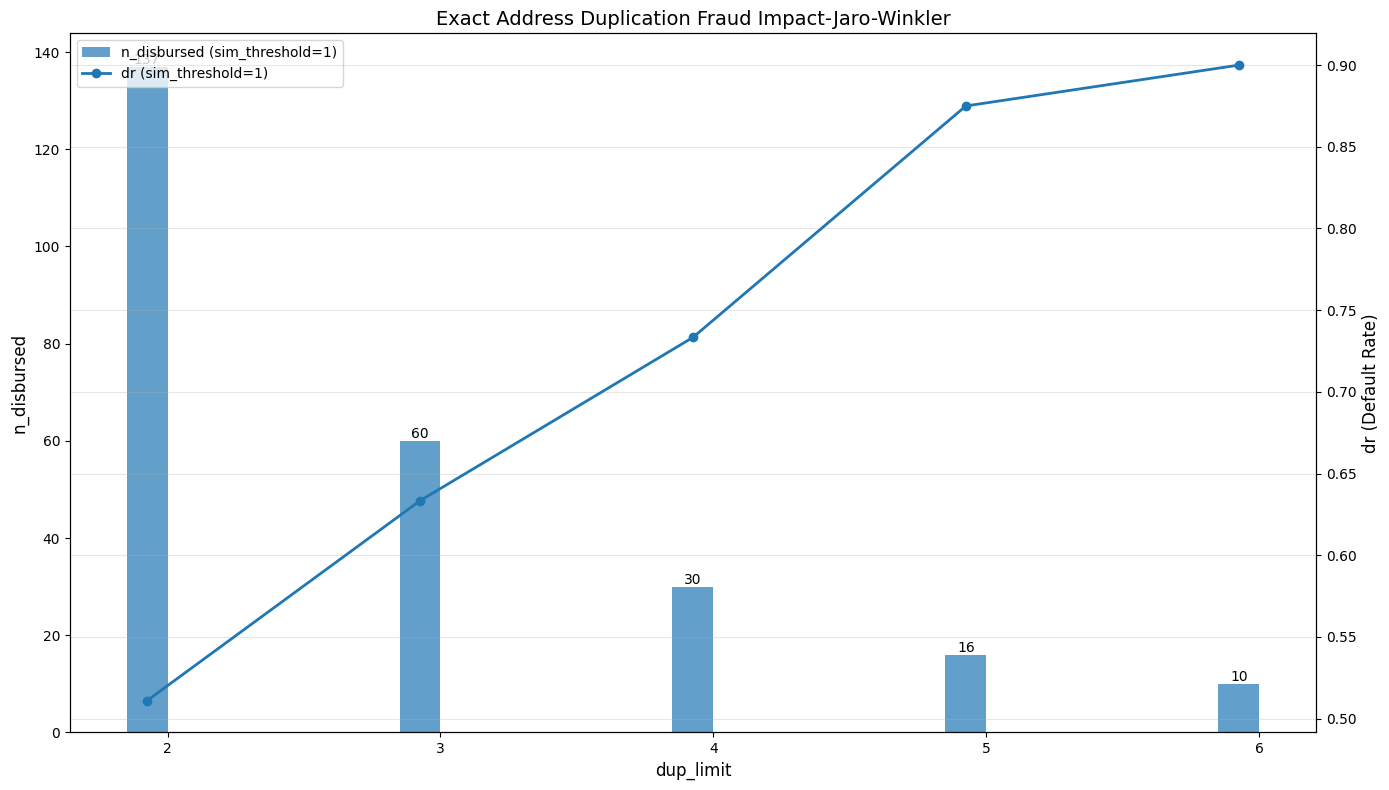

In [22]:
add_multi_chart(output3, 'Exact Address Duplication Fraud Impact-Jaro-Winkler', 'dup_limit', 'sim_threshold')

MultiColumn Duplications Iterations

In [8]:
# records = []
# for i in range(2, 6):
#     output = defaultdict(list) 
#     res = lev_win(df, 15, i, 3)
#     output['dup_limit'] = i
#     output['n_surveys'] = res['CLIENT_ID'].count()
#     output['n_disbursed'] = res['DISBURSED'].sum()
#     output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
#     records.append(output)



In [24]:
from modules.distance_finder import jaro_win_multi

In [26]:
#iterating over range for position similarity
records = []
for i in range(2, 6):
   
    output = defaultdict(list) 
    res = jaro_win_multi(df, 15, 0.85, 0.85, i)
    res['dup_limit'] = i
    # res['pos_sim'] = j
    output['dup_limit'] = i
    output['pos_sim'] = 0.85
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

In [27]:
output5 = pd.DataFrame(records)
output5

,dup_limit,pos_sim,n_surveys,n_disbursed,dr
0,2,0.85,115,75,0.826667
1,3,0.85,77,48,0.875000
2,4,0.85,50,28,1.000000
3,5,0.85,34,18,1.000000


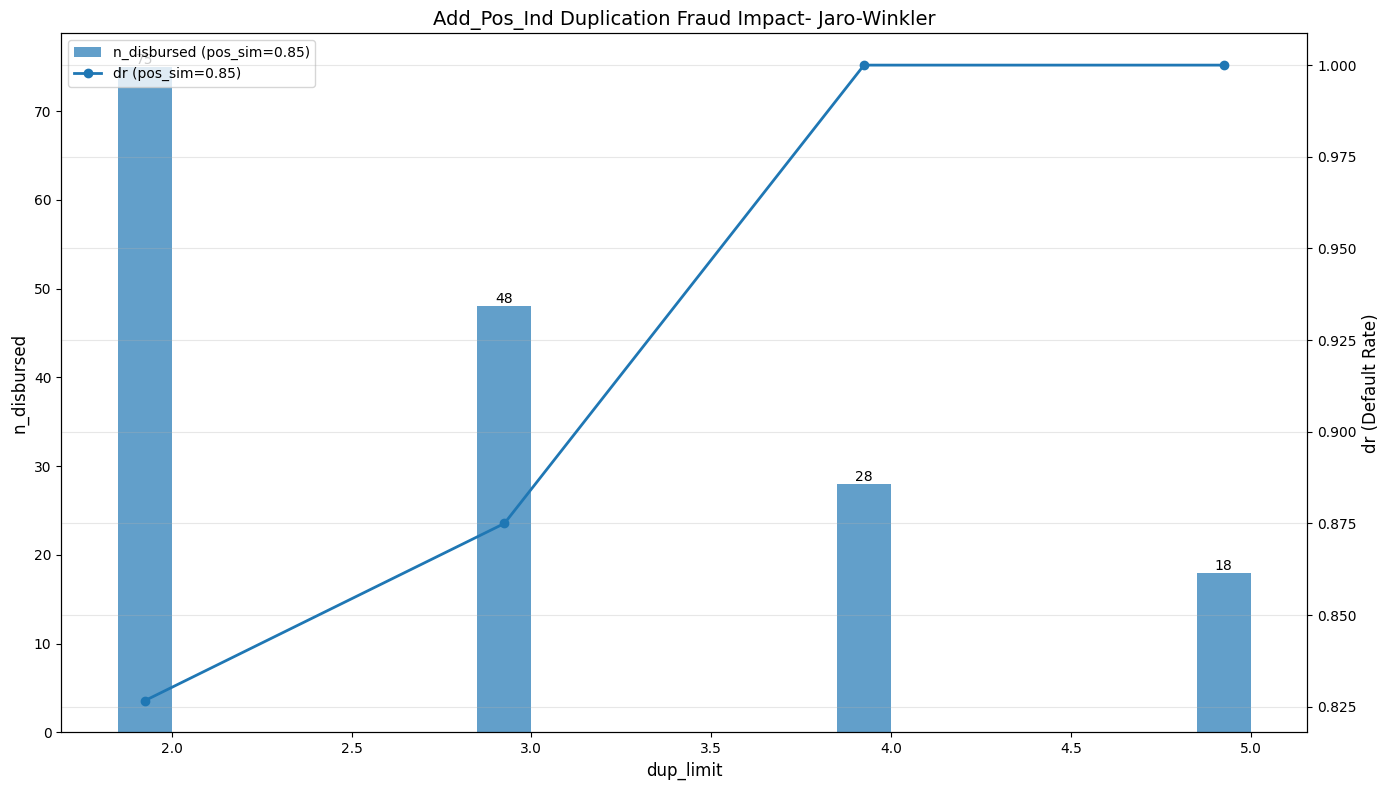

In [28]:
add_multi_chart(output5, 'Add_Pos_Ind Duplication Fraud Impact- Jaro-Winkler', 'dup_limit', 'pos_sim')

In [29]:
add_pos_dup = res.copy()

In [30]:
add_pos_dup.to_csv('add_pos_dup-jaro-winkler.csv')

In [31]:
data = pd.read_csv('surveys Q1 2025.csv')
data['SURVEY_DATE'] = pd.to_datetime(data['SURVEY_DATE'])

In [40]:
#iterating over range for position similarity
records = []
for i in range(2, 6):
   
    output = defaultdict(list) 
    res = jaro_win_multi(data, 15, 0.80, 0.80, i)
    res['dup_limit'] = i
    # res['pos_sim'] = j
    output['dup_limit'] = i
    output['pos_sim'] = 0.80
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

In [41]:
add_pos_dup_q1 = res.copy()

In [42]:
output6 = pd.DataFrame(records)
output6

,dup_limit,pos_sim,n_surveys,n_disbursed,dr
0,2,0.85,53,18,0.888889
1,3,0.85,31,9,0.888889
2,4,0.85,16,5,1.000000
3,5,0.85,9,4,1.000000


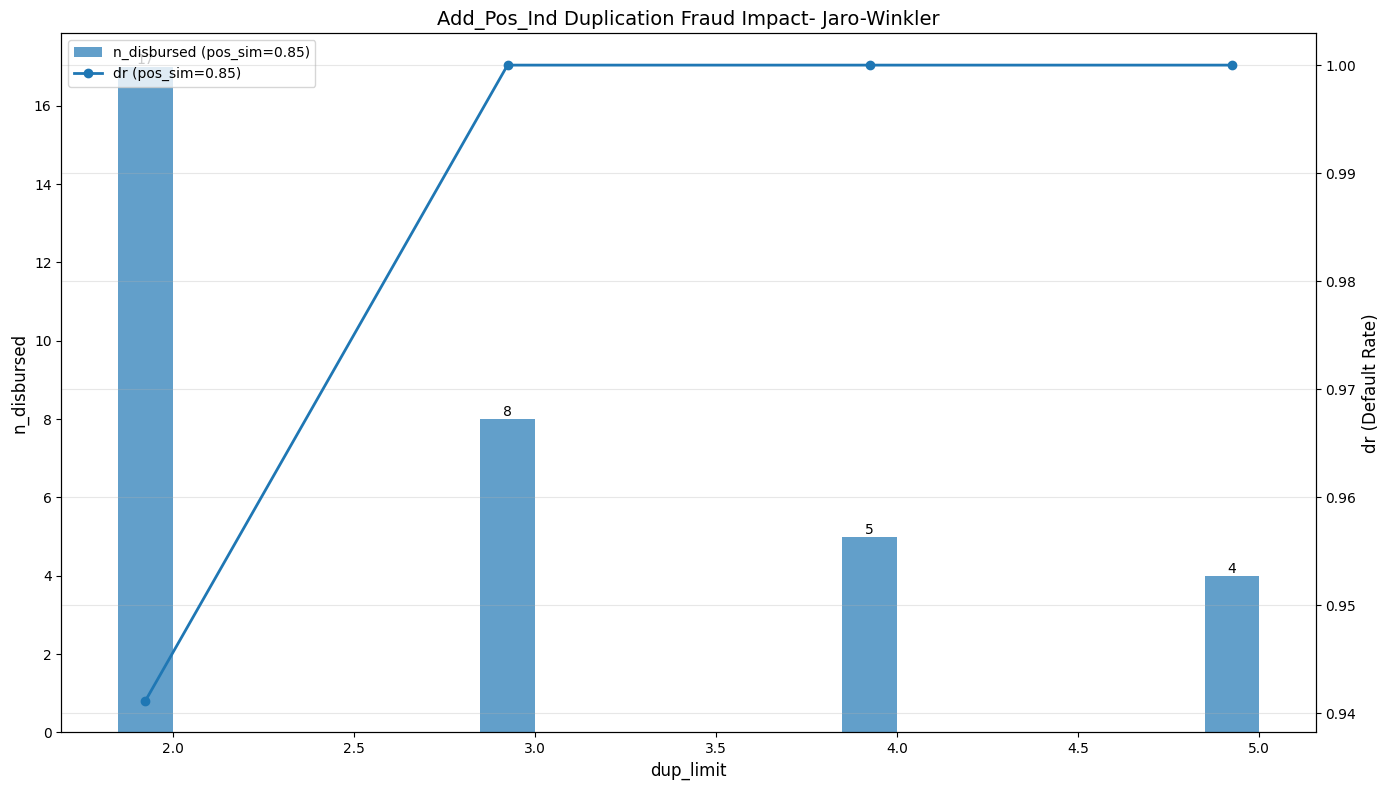

In [ ]:
add_multi_chart(output6, 'Add_Pos_Ind Duplication Fraud Impact- Jaro-Winkler', 'dup_limit', 'pos_sim')

In [11]:
# #iterating over range for position similarity
# records = []
# for i in range(2, 6):
#     for j in [0.75, 0.80, 0.85]:
#         output = defaultdict(list) 
#         res = lev_win_multi(df, 15, 0.80, j, i)
#         res['dup_limit'] = i
#         res['pos_sim'] = j
#         output['dup_limit'] = i
#         output['pos_sim'] = j
#         output['n_surveys'] = res['CLIENT_ID'].count()
#         output['n_disbursed'] = res['DISBURSED'].sum()
#         output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
#         records.append(output)

In [11]:
multi_jw_res = res.copy()

In [ ]:
multi_jw_res

In [ ]:
output4 = pd.DataFrame(records)
output4

,dup_limit,pos_sim,n_surveys,n_disbursed,dr
0,2,0.75,58357,30858,0.190745
1,2,0.80,45207,24206,0.190697
2,2,0.85,29790,16350,0.195902
3,3,0.75,42341,22585,0.191410
4,3,0.80,31901,17234,0.190263
5,3,0.85,19443,10805,0.195373
6,4,0.75,31860,17090,0.192686
7,4,0.80,23419,12728,0.190132
8,4,0.85,13067,7361,0.196577
9,5,0.75,24401,13073,0.191310


In [17]:
#iterating over range for dup threshold 
records = []
for i in range(2, 6):
    output = defaultdict(list) 
    res = lev_win_multi(df, 15, 3,4, i)
    output['dup_limit'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

output5 = pd.DataFrame(records)
output5

,dup_limit,n_surveys,n_disbursed,dr
0,2,126,63,0.650794
1,3,85,42,0.690476
2,4,55,26,0.769231
3,5,35,14,0.642857


In [18]:
#iterating over range for position similarity
records = []
for i in range(2, 7):
    output = defaultdict(list) 
    res = lev_win_multi(df, 15, 3, i, 2)
    output['pos_sim'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)


output6 = pd.DataFrame(records)
output6

,pos_sim,n_surveys,n_disbursed,dr
0,2,115,58,0.655172
1,3,122,61,0.655738
2,4,126,63,0.650794
3,5,135,71,0.661972
4,6,144,76,0.671053


In [19]:
records = []
for i in range(2, 7):
    for j in range(2,6):
        output = defaultdict(list) 
        res = lev_win_multi(df, 15, 3, i, j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output7 = pd.DataFrame(records)
output7

,pos_sim,dup_limit,n_surveys,n_disbursed,dr
0,2,2,115,58,0.655172
1,2,3,76,38,0.657895
2,2,4,48,21,0.714286
3,2,5,32,12,0.583333
4,3,2,122,61,0.655738
5,3,3,83,42,0.690476
6,3,4,53,24,0.750000
7,3,5,33,12,0.583333
8,4,2,126,63,0.650794
9,4,3,85,42,0.690476


In [20]:
import matplotlib.pyplot as plt

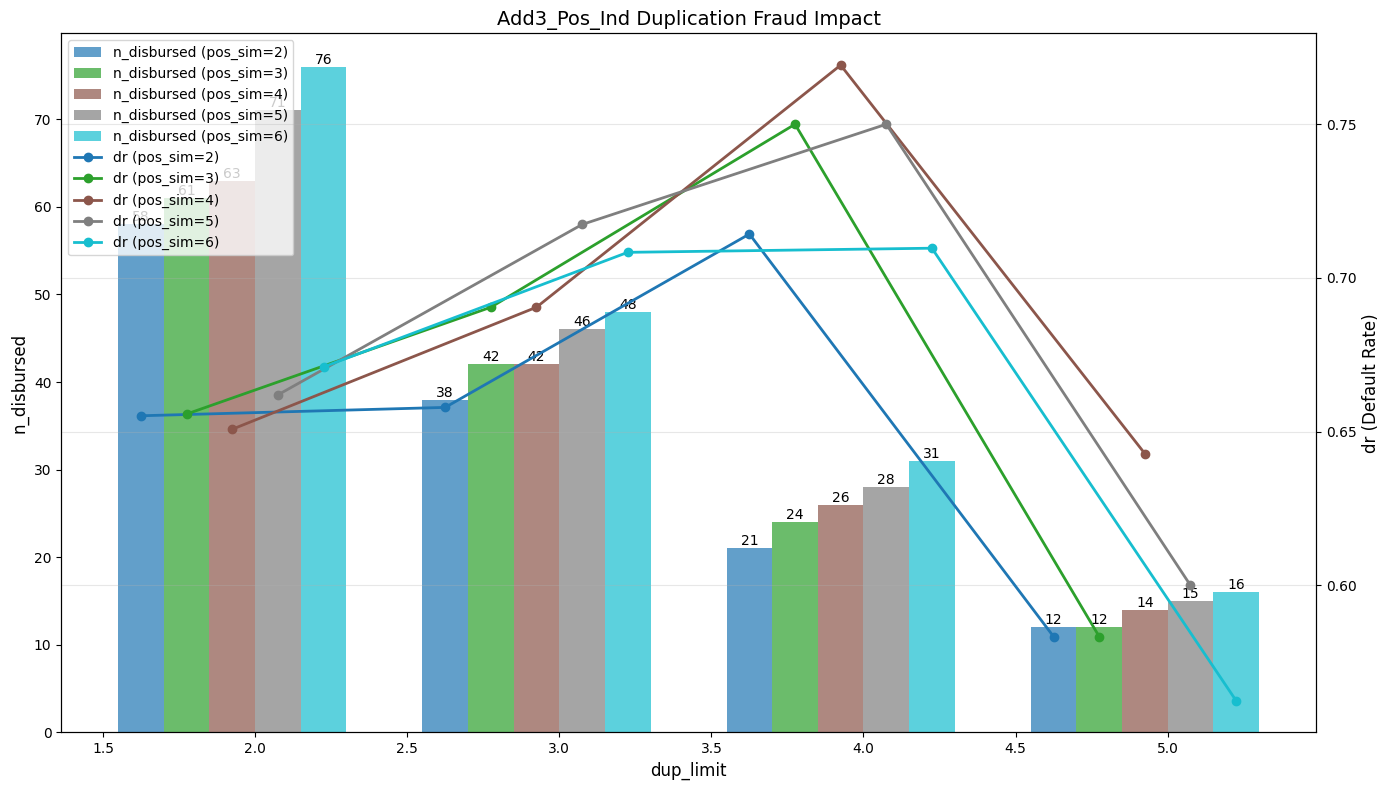

In [33]:
add_multi_chart(output7, 'Add3_Pos_Ind Duplication Fraud Impact', 'dup_limit', 'pos_sim')

In [22]:
records = []
for i in range(3, 6):
    for j in range(2, 5):
        output = defaultdict(list) 
        res = lev_win(df, 15, j, i)
        output['dup_limit'] = j
        output['add_sim'] = i
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output9 = pd.DataFrame(records)

In [23]:
output9

,dup_limit,add_sim,n_surveys,n_disbursed,dr
0,2,3,3982,2005,0.248878
1,3,3,2010,1034,0.255319
2,4,3,1188,637,0.244898
3,2,4,7101,3500,0.227714
4,3,4,3795,1882,0.232200
5,4,4,2253,1132,0.226148
6,2,5,15269,7431,0.210739
7,3,5,9567,4743,0.211680
8,4,5,6520,3273,0.214788


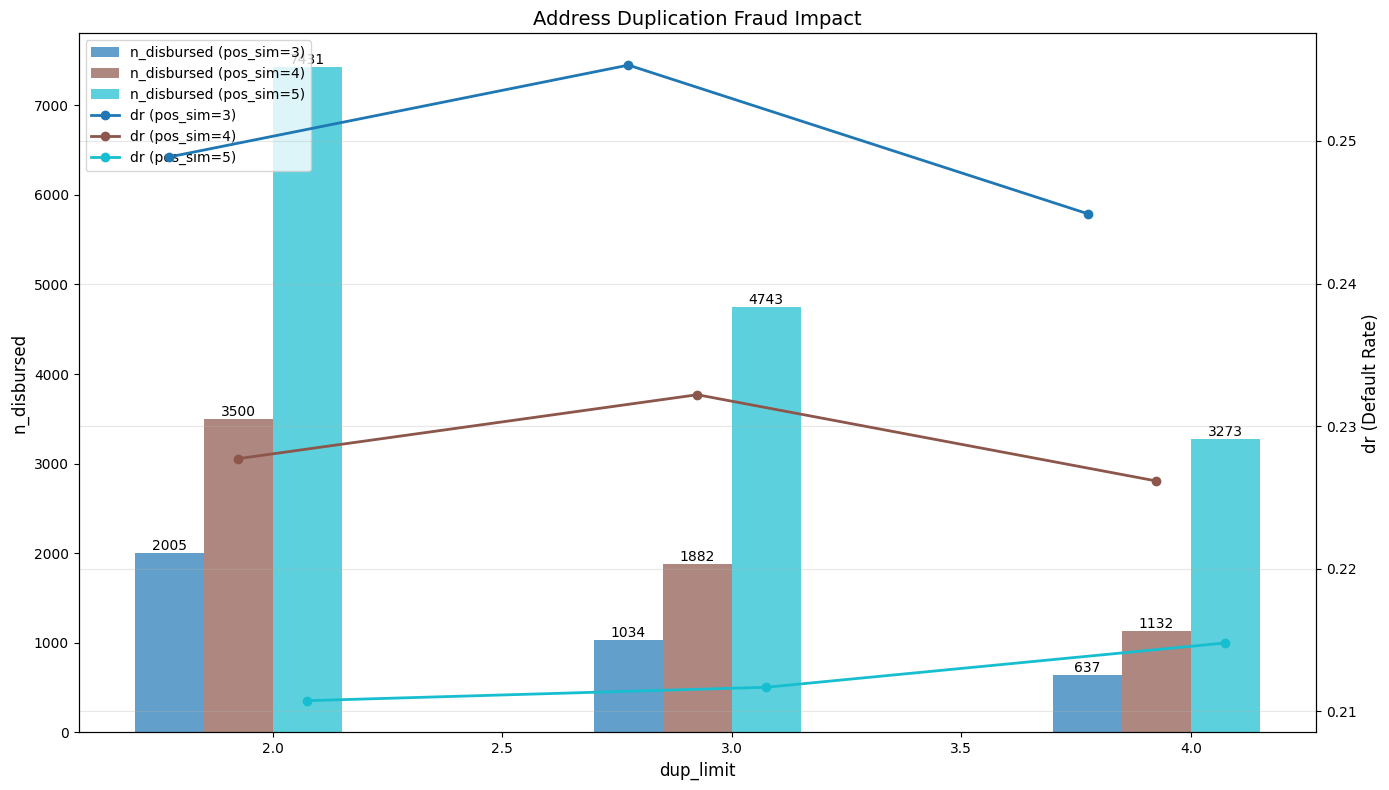

In [34]:
add_multi_chart(output9, 'Address Duplication Fraud Impact', 'dup_limit', 'add_sim')

In [25]:
records = []
for i in range(2, 7):
    for j in range(2,6):
        output = defaultdict(list) 
        res = lev_win_multi(df, 15, 2, i, j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output10 = pd.DataFrame(records)
output10

,pos_sim,dup_limit,n_surveys,n_disbursed,dr
0,2,2,111,56,0.660714
1,2,3,72,37,0.648649
2,2,4,44,20,0.700000
3,2,5,29,12,0.583333
4,3,2,118,59,0.661017
5,3,3,79,41,0.682927
6,3,4,49,23,0.739130
7,3,5,30,12,0.583333
8,4,2,122,61,0.655738
9,4,3,81,41,0.682927


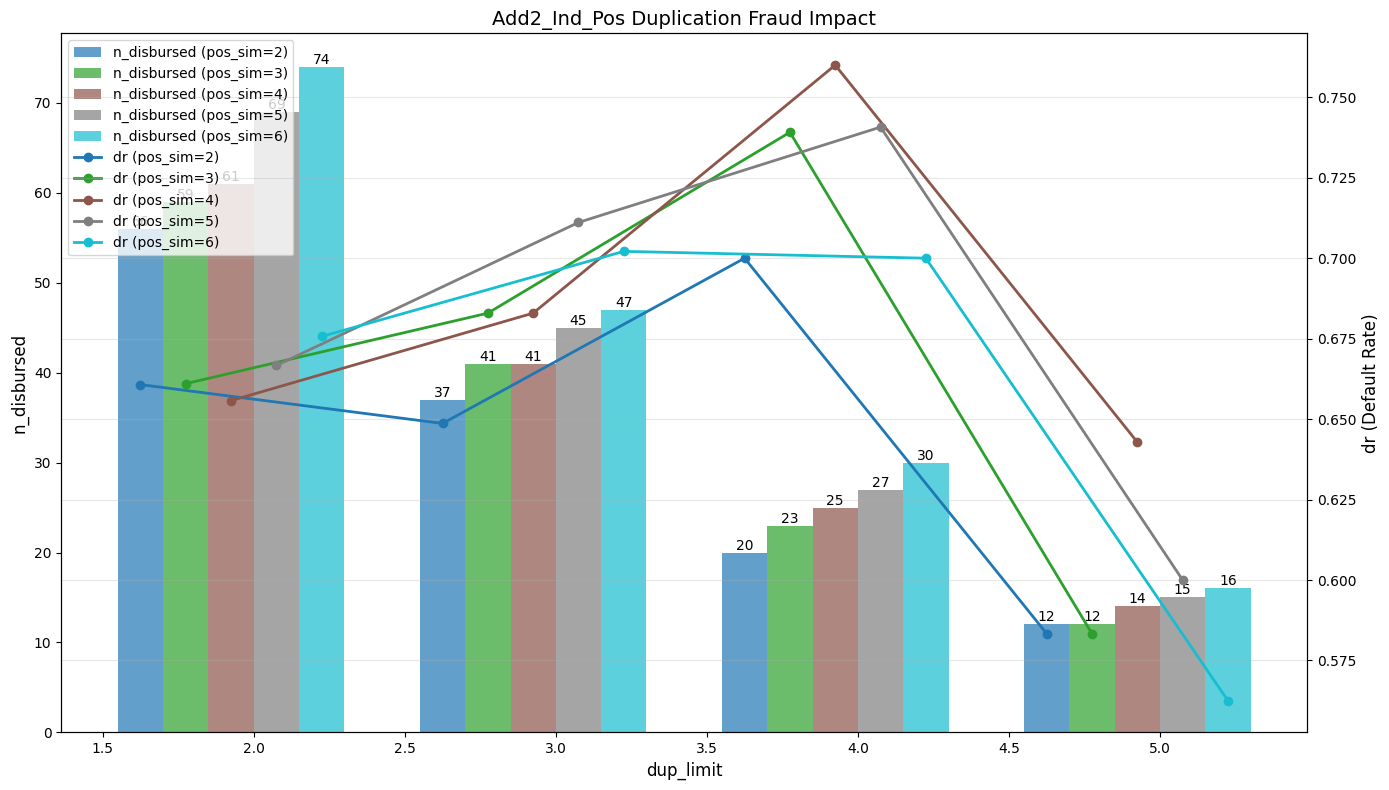

In [35]:
add_multi_chart(output10, 'Add2_Ind_Pos Duplication Fraud Impact', 'dup_limit', 'pos_sim')

In [ ]:
records = []
for i in range(2, 7):
    for j in range(2,6):
        output = defaultdict(list) 
        res = lev_win_multi(df, 15, 4, i, j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output12 = pd.DataFrame(records)
output12


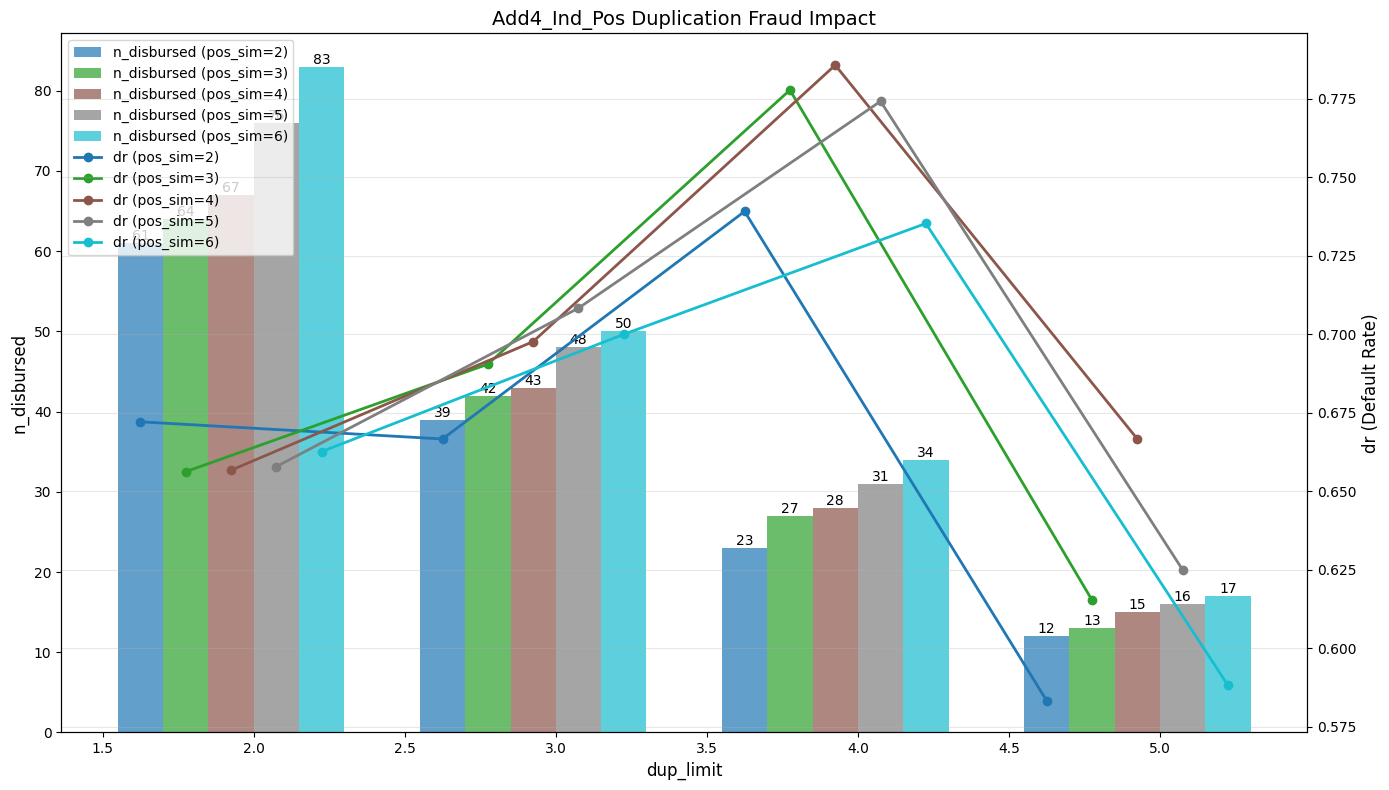

In [36]:
add_multi_chart(output12, 'Add4_Ind_Pos Duplication Fraud Impact', 'dup_limit', 'pos_sim')

In [37]:
from modules.distance_finder import lev_win_pos_ind

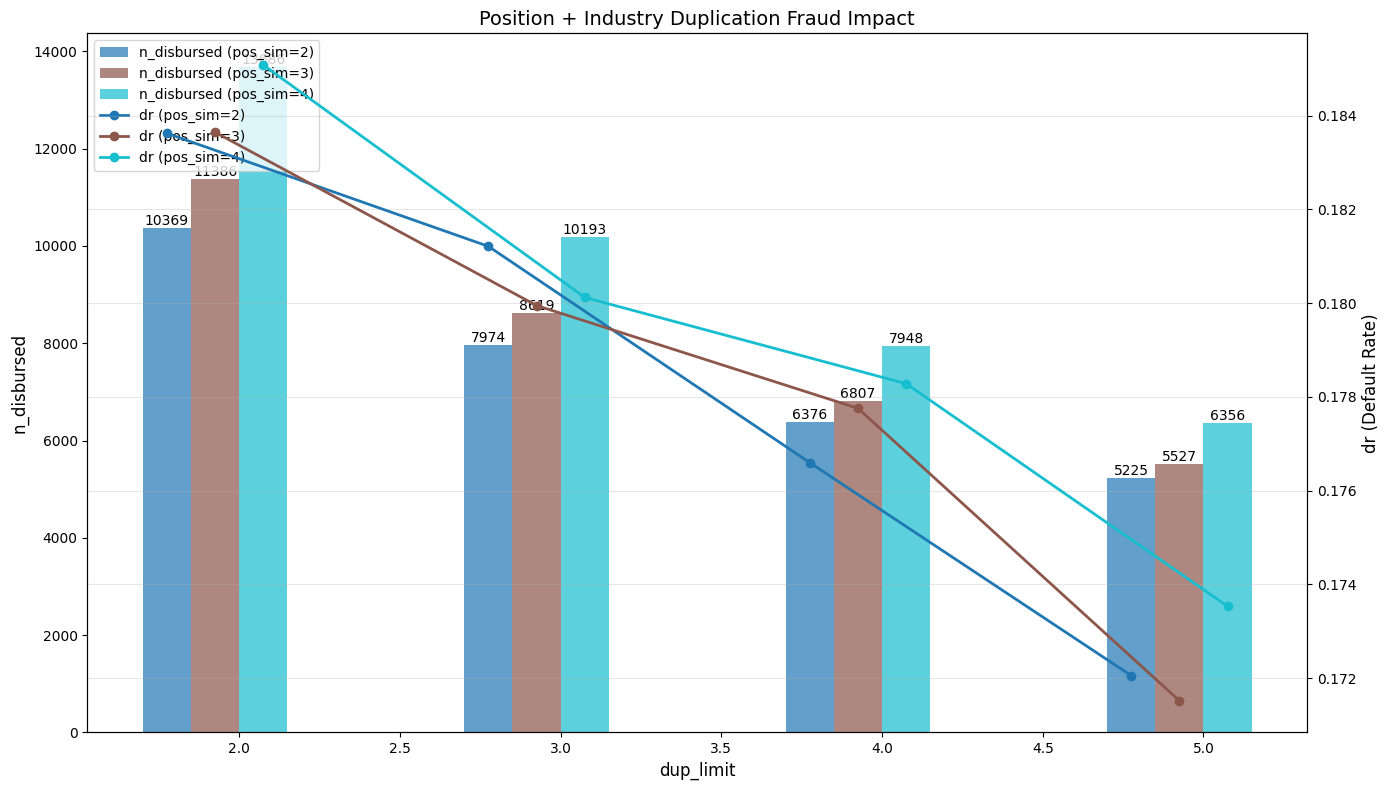

In [39]:
# Testing lev_win_pos_ind
records = []
for i in range(2, 5):  # position similarity threshold
    for j in range(2, 6):  # duplication limit
        output = defaultdict(list) 
        res = lev_win_pos_ind(df, 15, i, j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum() if res['DISBURSED'].sum() > 0 else 0
        records.append(output)
results = pd.DataFrame(records)


add_multi_chart(results, 'Position + Industry Duplication Fraud Impact-GH', 'dup_limit', 'pos_sim')

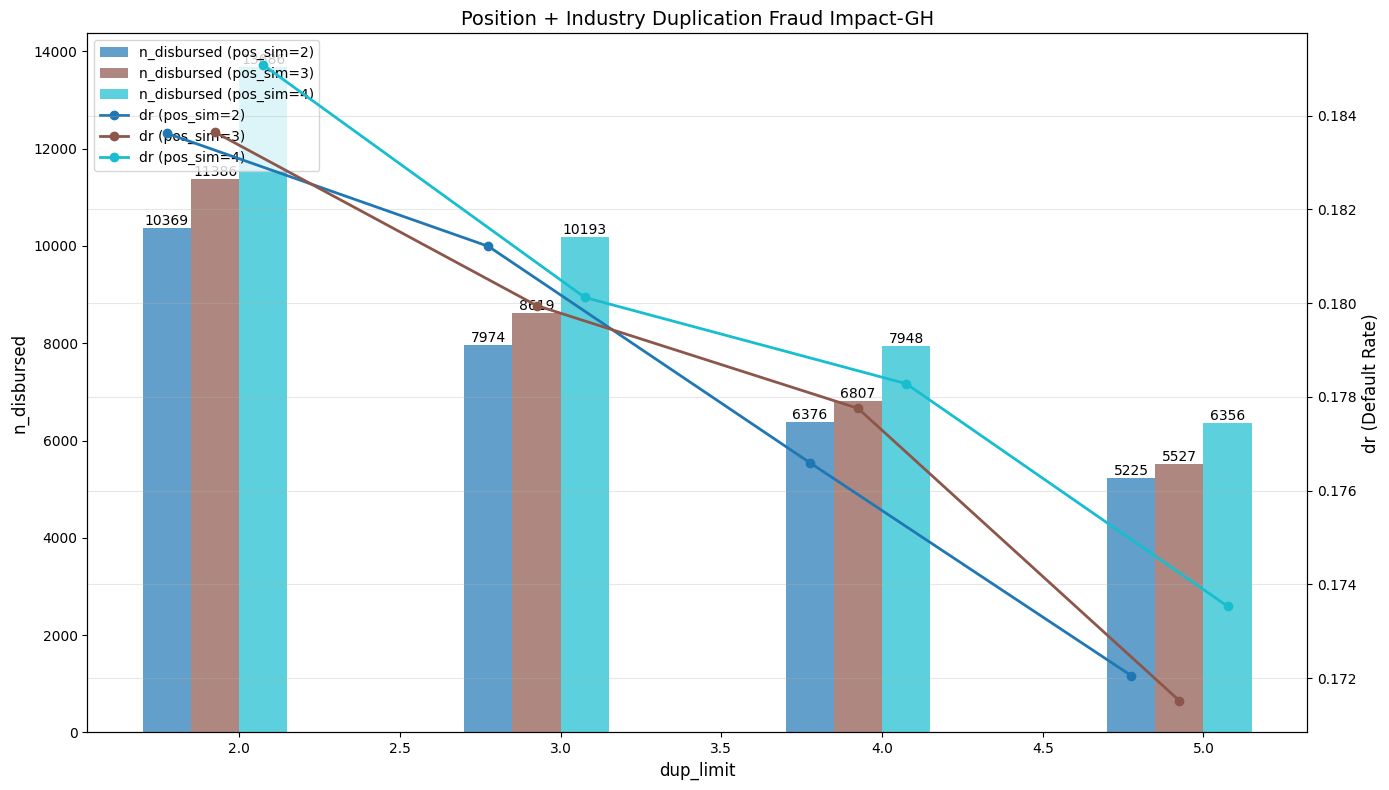

In [40]:
add_multi_chart(results, 'Position + Industry Duplication Fraud Impact-GH', 'dup_limit', 'pos_sim')

In [41]:
res.head()

,HASH,SURVEY_DATE,ADDRESS,POSITION,INDUSTRY,FRAUD_TYPE,SIMILAR_PRIOR_POSITION,SIMILAR_PRIOR_ADDRESS,SIMILAR_SURVEY_COUNT,CLIENT_ID,SURVEY_WEEK,EMAIL,DISB_DATE,DISBURSED,DR1,DEFAULTED,PTFRAUD
0,ebyez,2024-02-14 10:04:13,Busmankwa street,NaN,NaN,MULTIPLE_POS_ADD_IND_DUPS,nan,Tarkwa station,7,639602164,2024-02-12,parkerlewismens@gmail.com,NaN,0,0,0,0
1,ebyez,2024-02-15 13:16:20,Christ Ntsi st,NaN,NaN,MULTIPLE_POS_ADD_IND_DUPS,nan,Tarkwa station,8,212663909,2024-02-12,lorriettab@gmail.com,2024-02-15 16:11:00.000,1,0,0,0
2,ebyez,2024-02-15 15:55:32,Osam close,NaN,NaN,MULTIPLE_POS_ADD_IND_DUPS,nan,Kiafe Lodge,9,666280662,2024-02-12,NaN,2024-02-15 18:22:48.000,1,0,0,0
3,ebyez,2024-02-16 15:46:42,J Cross Cole Street,NaN,NaN,MULTIPLE_POS_ADD_IND_DUPS,nan,C488 Cocktail street,10,332953133,2024-02-12,Solomontachie.000@email.com,2024-02-18 13:28:33.000,1,0,0,0
4,ebyez,2024-02-21 14:22:37,House number 12,NaN,NaN,MULTIPLE_POS_ADD_IND_DUPS,nan,Kiafe Lodge,9,896719352,2024-02-19,arkorfulesthella@gmail.com,NaN,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12918,s126f,2024-09-06 20:59:09,Pentecost Church,Teacher,Education,MULTIPLE_POS_ADD_IND_DUPS,Teacher,Pentecost Church,9,196678522,2024-09-02,NaN,2024-09-06 21:13:59.000,1,1,0,1
12919,s126f,2024-09-09 20:59:32,Hope city,teacher,Education,MULTIPLE_POS_ADD_IND_DUPS,teacher,post office,8,339913584,2024-09-09,boatengmanu@gmail.com,2024-09-09 21:11:56.000,1,0,0,0
12920,s126f,2024-09-12 09:18:41,Pentecost Church,teacher,Education,MULTIPLE_POS_ADD_IND_DUPS,teacher,Pentecost Church,9,828691554,2024-09-09,NaN,2024-09-12 10:21:16.000,1,1,0,1
12921,s126f,2024-09-12 15:45:50,Pentecost Church,Teacher,Education,MULTIPLE_POS_ADD_IND_DUPS,Teacher,Pentecost Church,10,72434140,2024-09-09,NaN,2024-09-12 16:26:50.000,1,1,0,1
